# Copper (Cu) Concentration Predictor
This notebook predicts the concentration of Copper in an image and compares it with the expected value extracted from the filename.

In [31]:
import os
import re
import joblib
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from IPython.display import display

# Constants (Matching training settings)
MODEL_PATH = "model/cu_model.pkl"
CROP_BOX_WIDTH = 100
CROP_BOX_HEIGHT = 100
CROP_OFFSET_X = 65
CROP_OFFSET_Y = 750

if not os.path.exists(MODEL_PATH):
    print(f"Model not found at {MODEL_PATH}. Please run the training notebook first!")

In [32]:
def process_image(image_path):
    """Extract RGB values and normalization features like the training script."""
    img = Image.open(image_path).convert("RGB")
    w, h = img.size

    # Calculate crop coordinates
    left = max((w - CROP_BOX_WIDTH) // 2 + CROP_OFFSET_X, 0)
    top = max((h - CROP_BOX_HEIGHT) // 2 + CROP_OFFSET_Y, 0)
    right = min(left + CROP_BOX_WIDTH, w)
    bottom = min(top + CROP_BOX_HEIGHT, h)

    cropped = img.crop((left, top, right, bottom))
    arr = np.array(cropped, dtype=np.float64)

    mean_r = arr[:, :, 0].mean()
    mean_g = arr[:, :, 1].mean()
    mean_b = arr[:, :, 2].mean()
    
    total_rgb = mean_r + mean_g + mean_b
    
    # Create a single-row dataframe for the model
    features = pd.DataFrame([{
        "mean_R": mean_r,
        "mean_G": mean_g,
        "mean_B": mean_b,
        "r_norm": mean_r / total_rgb,
        "g_norm": mean_g / total_rgb,
        "b_norm": mean_b / total_rgb
    }])
    
    return features, img, cropped, (left, top, right, bottom)

def extract_expected_value(image_path):
    """
    Parse the concentration value from the filename.
    Example: '0,5a (1).jpg' -> 0.5
    """
    filename = os.path.basename(image_path)
    name = os.path.splitext(filename)[0]
    
    # Pattern for filenames starting with "B" prefix (e.g., "B0,1(1)", "B2,5(3)")
    m = re.match(r'^[Bb](\d+[,.]?\d*)', name)
    if m:
        return float(m.group(1).replace(',', '.'))

    # Pattern for standard naming: number at start, possibly with comma decimal
    m = re.match(r'^(\d+[,.]?\d*)', name)
    if m:
        return float(m.group(1).replace(',', '.'))

    return None

def predict_concentration(image_path):
    if not os.path.exists(image_path):
        print(f"Error: Image file '{image_path}' not found.")
        return
        
    # Load model artifact
    artifact = joblib.load(MODEL_PATH)
    pipeline = artifact["pipeline"]
    
    # Process image
    features, original_img, cropped_img, box = process_image(image_path)
    left, top, right, bottom = box
    
    # Predict
    prediction = pipeline.predict(features)[0]
    
    # Expected Value Extraction
    expected = extract_expected_value(image_path)
    
    # Display Visualization
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # 1. Original image with red crop box
    ax1.imshow(original_img)
    rect = patches.Rectangle((left, top), right-left, bottom-top, linewidth=2, edgecolor='r', facecolor='none', label='Crop Area')
    ax1.add_patch(rect)
    ax1.set_title("Original Image (Showing Crop Box)")
    ax1.axis('off')
    
    # 2. Cropped image (what the model sees)
    ax2.imshow(cropped_img)
    ax2.set_title("Analyzed Region (100x100 Crop)")
    ax2.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Console Output Summary
    print("\n" + "="*50)
    print(" PREDICTION RESULTS ")
    print("="*50)
    print(f" Image:           {os.path.basename(image_path)}")
    print(f" Predicted Cu:    {prediction:.4f} mg/L")
    
    if expected is not None:
        residual = prediction - expected
        abs_error = abs(residual)
        error_pct = (abs_error / expected * 100) if expected != 0 else 0
        
        print(f" Expected Cu:     {expected:.4f} mg/L")
        print(f" Residual Error: {residual:+.4f} mg/L")
        print(f" Absolute Error: {abs_error:.4f} mg/L")
        print(f" Error Percentage: {error_pct:.2f}%")
    else:
        print(" Expected Cu:     Not available (filename is not a number)")
    
    print("-"*50)
    print(f" Mean RGB:       R={features['mean_R'][0]:.2f}, G={features['mean_G'][0]:.2f}, B={features['mean_B'][0]:.2f}")
    print(f" Normalization:  r={features['r_norm'][0]:.4f}, g={features['g_norm'][0]:.4f}, b={features['b_norm'][0]:.4f}")
    print("="*50)

### Select Image to Test
Change the path below to test a different image.

c:\College_Computer_Science\PIPP\tutor-ai-farmasi\ai_train\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


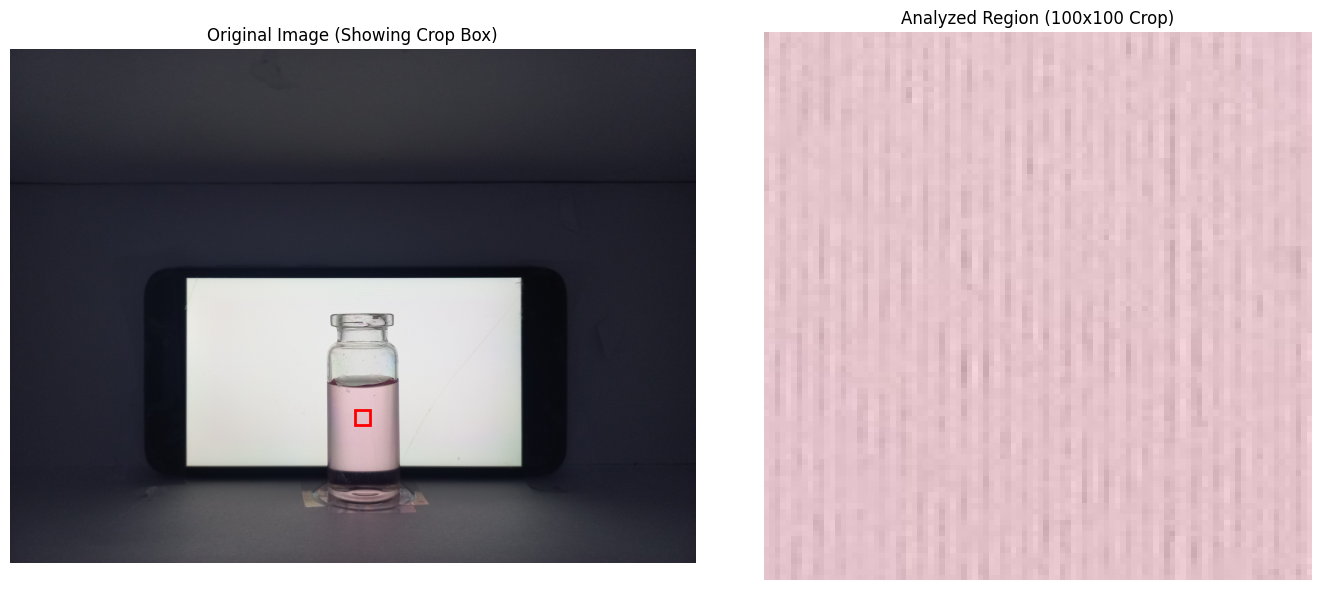


 PREDICTION RESULTS 
 Image:           2,5a (1).jpg
 Predicted Cu:    2.4470 mg/L
 Expected Cu:     2.5000 mg/L
 Residual Error: -0.0530 mg/L
 Absolute Error: 0.0530 mg/L
 Error Percentage: 2.12%
--------------------------------------------------
 Mean RGB:       R=226.87, G=194.91, B=201.61
 Normalization:  r=0.3639, g=0.3127, b=0.3234


In [33]:
image_to_test = "dataset/cu_pict/2,5a (1).jpg"  # Replace with your test image path

predict_concentration(image_to_test)